### Build Model and Train

In [1]:
# Imports
import os, sys
import torch
import numpy as np

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
model_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "src"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
sys.path.append(model_dir)
from data_processing import load_cluster
from yaml_processor import load_config, save_config
from sensor_processing import sensor_processing

from EDM import EDM

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
import matplotlib.pyplot as plt

In [3]:
# Parameters
cluster = 0
chkpnt_path = os.path.join(output_dir, "model_checkpoint", str(cluster))
nt = config_global["data"]["nt"]
T = 1/np.pi
t = np.linspace(0, T, nt)
dt = t[1]-t[0]

In [4]:
# Set device
device = ('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load Data
FS_train, params_train, ft_train, disp_norm, vel_norm, ft_norm = load_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, normalize=True)
FS_val, params_val, ft_val, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, True, disp_norm, vel_norm, ft_norm)
FS_test, params_test, ft_test, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, True, disp_norm, vel_norm, ft_norm)

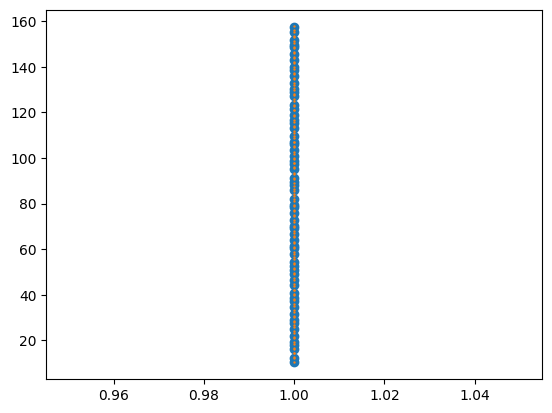

In [5]:
plt.figure()
plt.scatter(np.ones(params_train.shape[0]), params_train)
plt.scatter(np.ones(params_test.shape[0]), params_test, s=0.5)

In [6]:
# Apply Sensor Placement
sp = sensor_processing(FS_train[:, 1], config_global)
A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(output_dir)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

# Reshape
n_dim = RS_train.shape[1]
RS_train = np.concatenate([RS_train[:, i, :, :] for i in range(n_dim)], axis=-1)
RS_val = np.concatenate([RS_val[:, i, :, :] for i in range(n_dim)], axis=-1)
RS_test = np.concatenate([RS_test[:, i, :, :] for i in range(n_dim)], axis=-1)

##### Import Model

In [7]:
model = EDM(A_Mat, pinv_Theta, dt, config_global, device)

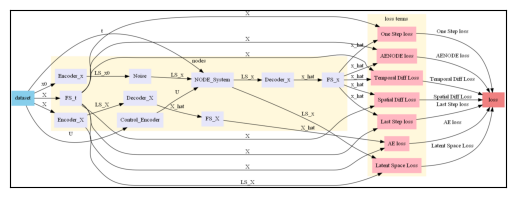

In [8]:
# "rbf_lpv_resid" worked best so far
model.build_model(gate_config="narrow", method="ssm", indx_q=1)

In [9]:
problem = model.train_model(chkpnt_path, RS_train, ft_train, RS_val, ft_val, data_test=RS_test,  ft_test=ft_test, t=t[:, np.newaxis])

None
Number of parameters: 289034

 Current Learning Rate - 0.001
epoch: 0	train_loss: 3.42285	val_loss: 4.57463	eltime:  2.97267
epoch: 1	train_loss: 2.86558	val_loss: 4.21943	eltime:  6.86603
epoch: 2	train_loss: 2.76355	val_loss: 4.16245	eltime:  10.75466
epoch: 3	train_loss: 2.75212	val_loss: 4.02699	eltime:  15.76203
epoch: 4	train_loss: 2.66390	val_loss: 3.83480	eltime:  19.09744
epoch: 5	train_loss: 2.47125	val_loss: 3.46905	eltime:  23.61638
epoch: 6	train_loss: 2.21736	val_loss: 3.08763	eltime:  27.30683
epoch: 7	train_loss: 2.18992	val_loss: 2.93491	eltime:  31.87635
epoch: 8	train_loss: 2.09488	val_loss: 2.70691	eltime:  35.24490
epoch: 9	train_loss: 1.88942	val_loss: 2.47580	eltime:  39.48337
epoch: 10	train_loss: 1.83694	val_loss: 2.23237	eltime:  42.76238
epoch: 11	train_loss: 1.59478	val_loss: 1.94765	eltime:  46.93308
epoch: 12	train_loss: 1.49566	val_loss: 1.78052	eltime:  50.69782
epoch: 13	train_loss: 1.39705	val_loss: 1.65826	eltime:  56.53115
epoch: 14	train_loss: 

In [ ]:
import os

In [ ]:
os.system("rundll32.exe powrprof.dll,SetSuspendState 0,1,0")

0